In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import optuna

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from optuna.visualization.matplotlib import plot_optimization_history
from optuna.visualization.matplotlib import plot_param_importances

### Шаг 1. Загрузка и разделение данных

In [2]:
df = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s15t3_exoplanet_regression.csv')

print(f"Размер выборки: {df.shape}")

print("\nПервые строки выборки:")
print(df.head().T)

Размер выборки: (19761, 17)

Первые строки выборки:
                       0         1          2          3          4
pc1                0.036     0.029       0.04     -0.048      0.012
pc2            -0.469118 -0.453369  -0.455314   0.062012  -0.189558
pc3            -0.051703  0.408759   0.015327   0.022569   0.008973
ra                   317       194        192         94        340
dec                  -63        31         79         61        -71
j_mag             14.254    14.326     14.366     14.528     14.528
h_mag               13.9    13.911     14.064     14.113     14.113
k_mag             13.826    13.809     13.952     14.132     14.132
kep_mag           15.436    15.597     15.509     15.714     15.714
orbital_period     35677     47532      18872      11524       2194
star_teff         5853.0    5805.0     6031.0     6046.0     6046.0
star_logg          4.544     4.564      4.438      4.486      4.486
star_radius        0.868     0.791      1.046      0.972      0.

In [3]:
X = df.drop(columns=['planet_radius'])
y = df['planet_radius']

# Разделите данные
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=616)

print(f'Размер обучающей выборки: {X_train.shape}')
print(f'Размер тестовой выборки: {X_test.shape}')

Размер обучающей выборки: (15808, 16)
Размер тестовой выборки: (3953, 16)


### Шаг 2. Трансформер для предобработки признаков

In [4]:
preprocessor = ColumnTransformer([
    ('ohe_label', OneHotEncoder(handle_unknown='ignore'), ['label'])
], remainder='passthrough')

print(preprocessor)

ColumnTransformer(remainder='passthrough',
                  transformers=[('ohe_label',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['label'])])


### Шаг 3. Обучение базовых моделей

In [5]:
model_tree = DecisionTreeRegressor(random_state=616)  # Создайте модель DecisionTreeRegressor
model_bagging = BaggingRegressor(estimator= DecisionTreeRegressor(random_state=616), n_estimators=50, random_state=616)  # Создайте модель BaggingRegressor с n_estimators=50
model_rf = RandomForestRegressor(n_estimators=50, max_features='sqrt', random_state=616)  # Создайте модель RandomForestRegressor с n_estimators=50 и max_features='sqrt'

# Объявите пайплайны
pipe_tree = Pipeline([
    ('preprocessing', preprocessor),
    ('model', model_tree)
])
print("Пайплайн pipe_tree успешно создан.")

pipe_bagging = Pipeline([
    ('preprocessing', preprocessor),
    ('model', model_bagging)
])
print("Пайплайн pipe_bagging успешно создан.")

pipe_rf = Pipeline([
    ('preprocessing', preprocessor),
    ('model', model_rf)
])
print("Пайплайн pipe_rf успешно создан.")


Пайплайн pipe_tree успешно создан.
Пайплайн pipe_bagging успешно создан.
Пайплайн pipe_rf успешно создан.


### Шаг 4. Обучение пайплайнов и оценка качества

In [6]:
# Обучите пайплайны pipe_tree, pipe_bagging, pipe_rf
pipe_tree.fit(X_train, y_train)
pipe_bagging.fit(X_train, y_train)
pipe_rf.fit(X_train, y_train)

# Получите предсказания для тестовой выборки (X_test)
y_test_pred_tree = pipe_tree.predict(X_test)
y_test_pred_bagging = pipe_bagging.predict(X_test)
y_test_pred_rf = pipe_rf.predict(X_test)

In [7]:
# Допишите недостающий код для расчёта метрик
results = {
    'model': ['DesicionTree', 'Bagging', 'RandomForest'],
    'MAE': [mean_absolute_error(y_test, y_test_pred_tree), mean_absolute_error(y_test, y_test_pred_bagging), mean_absolute_error(y_test, y_test_pred_rf)],
    'MSE': [mean_squared_error(y_test, y_test_pred_tree), mean_squared_error(y_test, y_test_pred_bagging), mean_squared_error(y_test, y_test_pred_rf)],
    'R2': [r2_score(y_test, y_test_pred_tree), r2_score(y_test, y_test_pred_bagging), r2_score(y_test, y_test_pred_rf)]
}

df_metrics = pd.DataFrame(results)
print(df_metrics)

          model        MAE          MSE        R2
0  DesicionTree  10.353632  6473.770434 -0.311694
1       Bagging   8.601099  4820.887159  0.023208
2  RandomForest   8.951215  3710.727172  0.248145


### Шаг 5. Поиск гиперпараметров

In [8]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 100),
        'max_depth': trial.suggest_int('max_depth', 10, 50),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'max_samples': trial.suggest_float('max_samples', 0.7, 1.0)
    }

    model = RandomForestRegressor(**params, random_state=616)
    pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('model', model)
    ])
    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=3,
        scoring='r2'
    )

    return scores.mean()    

In [9]:
sampler = optuna.samplers.TPESampler(seed=616)
study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(objective, n_trials=25, show_progress_bar=True)

best_params = study.best_params # Возьмите лучшую комбинацию параметров из объекта study
best_value = study.best_value # Возьмите лучшее значение r2, округлив до трёх знаков после запятой
print(f"Лучшие гиперпараметры: {best_params}")
print(f"Лучшее значение r2: {best_value}")

[I 2026-07-06 13:54:32,034] A new study created in memory with name: no-name-478ae91c-e9a7-4784-8acb-92ed12582b2e
Best trial: 0. Best value: -0.0488669:   4%|▍         | 1/25 [00:53<21:16, 53.17s/it]

[I 2026-07-06 13:55:25,202] Trial 0 finished with value: -0.04886685865014854 and parameters: {'n_estimators': 89, 'max_depth': 47, 'max_features': None, 'max_samples': 0.7091895573579126}. Best is trial 0 with value: -0.04886685865014854.


Best trial: 0. Best value: -0.0488669:   8%|▊         | 2/25 [01:05<11:14, 29.31s/it]

[I 2026-07-06 13:55:37,812] Trial 1 finished with value: -0.09002078398065634 and parameters: {'n_estimators': 94, 'max_depth': 47, 'max_features': 'log2', 'max_samples': 0.7196615291102929}. Best is trial 0 with value: -0.04886685865014854.


Best trial: 0. Best value: -0.0488669:  12%|█▏        | 3/25 [01:15<07:32, 20.57s/it]

...

[I 2026-07-06 14:08:12,291] Trial 22 finished with value: -0.030183335541576966 and parameters: {'n_estimators': 88, 'max_depth': 33, 'max_features': None, 'max_samples': 0.7690815845575916}. Best is trial 21 with value: 0.018115717843879664.


Best trial: 21. Best value: 0.0181157:  96%|█████████▌| 24/25 [14:41<00:49, 49.75s/it]

[I 2026-07-06 14:09:13,529] Trial 23 finished with value: -0.15118270526356573 and parameters: {'n_estimators': 96, 'max_depth': 38, 'max_features': None, 'max_samples': 0.8354356695872325}. Best is trial 21 with value: 0.018115717843879664.


Best trial: 21. Best value: 0.0181157: 100%|██████████| 25/25 [15:36<00:00, 37.46s/it]

[I 2026-07-06 14:10:08,517] Trial 24 finished with value: -0.006813724022746641 and parameters: {'n_estimators': 90, 'max_depth': 44, 'max_features': None, 'max_samples': 0.7874159994504907}. Best is trial 21 with value: 0.018115717843879664.
Лучшие гиперпараметры: {'n_estimators': 90, 'max_depth': 36, 'max_features': None, 'max_samples': 0.7565468198727352}
Лучшее значение r2: 0.018115717843879664


C:\Users\mikhail.yakunin\AppData\Local\Temp\ipykernel_17004\4138976290.py:2: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  plot_optimization_history(study)
C:\Users\mikhail.yakunin\AppData\Local\Temp\ipykernel_17004\4138976290.py:5: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(study)


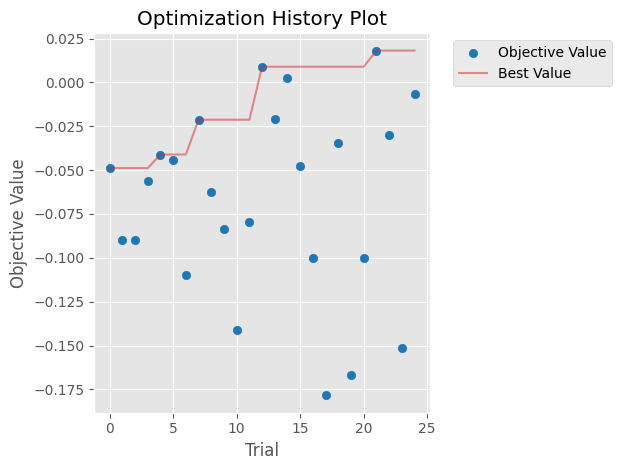

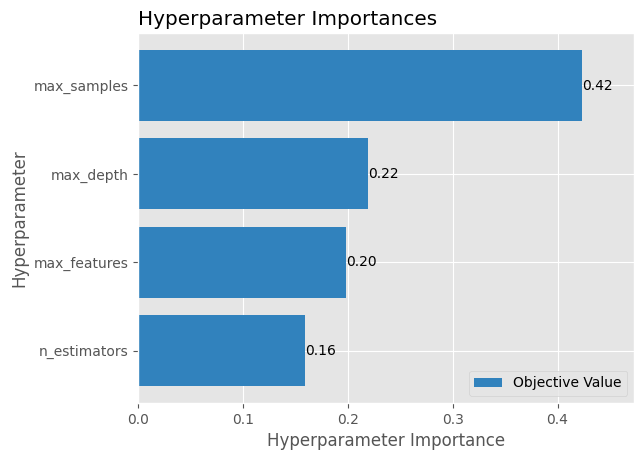

In [18]:
# Визуализация результатов
plot_optimization_history(study)

# Визуализация важности параметров
plot_param_importances(study)

plt.show()

### Шаг 6. Обучение лучшей модели

In [12]:
best_model = RandomForestRegressor(**best_params, random_state=616) # Создайте модель
best_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', best_model)
]) # Создайте пайплайн

# Обучите пайплайн и получите предсказание для X_test
best_pipeline.fit(X_train, y_train)
y_test_pred = best_pipeline.predict(X_test)

# Допишите код для подсчёта метрик
results = {
    "model": ["Best_RandomForest"],
    "MAE": [mean_absolute_error(y_test, y_test_pred)],
    "MSE": [mean_squared_error(y_test, y_test_pred)],
    "R2": [r2_score(y_test, y_test_pred)],
}
df_metrics = pd.concat([df_metrics, pd.DataFrame(results)], ignore_index=True)
print(df_metrics)

               model        MAE          MSE        R2
0       DesicionTree  10.353632  6473.770434 -0.311694
1            Bagging   8.601099  4820.887159  0.023208
2       RandomForest   8.951215  3710.727172  0.248145
3  Best_RandomForest   9.233858  4711.554567  0.045360
4  Best_RandomForest   9.055880  4024.737593  0.184521
5  Best_RandomForest   9.233858  4711.554567  0.045360


### Шаг 7. Оценка вклада признаков в предсказание

In [14]:
# Получите названия признаков и их важность из best_pipeline
feature_names = best_pipeline.named_steps['preprocessor'].get_feature_names_out()
importances = best_pipeline.named_steps['model'].feature_importances_

feature_importances = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

# Отсортируем по убыванию важности
feature_importances = feature_importances.sort_values(by='importance', ascending=False)

C:\Users\mikhail.yakunin\AppData\Local\Temp\ipykernel_17004\447243193.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


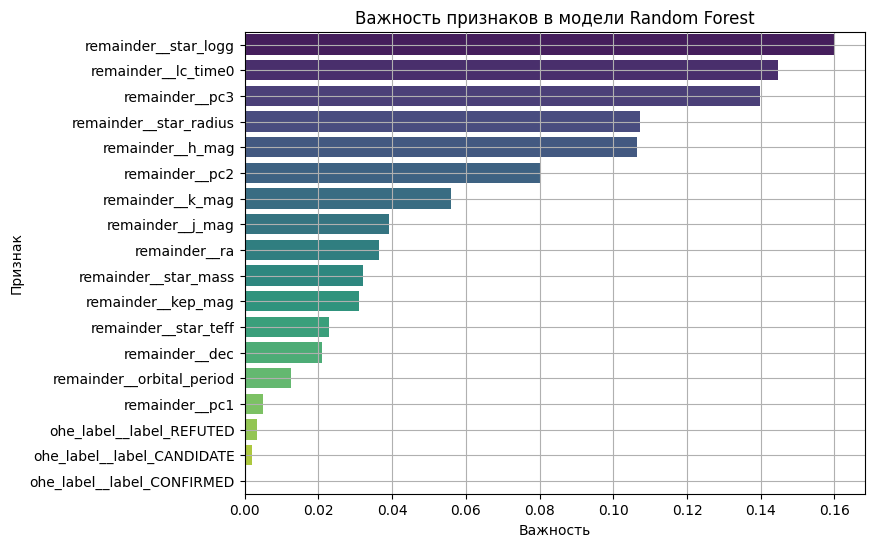

In [15]:
# Создадим график
plt.figure(figsize=(8, 6))
sns.barplot(
    data=feature_importances,
    x='importance',
    y='feature',
    palette='viridis'
)

plt.title('Важность признаков в модели Random Forest')
plt.xlabel('Важность')
plt.ylabel('Признак')
plt.grid()
plt.show()